In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
#import library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("/content/drive/MyDrive/ADEGuard/vaers_clean_dataset.csv", low_memory=False)

In [6]:
df.shape

(1025860, 4)

In [7]:
df.head()

,SYMPTOM_TEXT,SEX,AGE_GROUP,SEVERITY_LEVEL
0,Patient experienced mild numbness traveling fr...,F,Adult,Mild
1,C/O Headache,F,Adult,Mild
2,"felt warm, hot and face and ears were red and ...",F,Adult,Mild
3,within 15 minutes progressive light-headedness...,M,Adult,Mild
4,Pt felt wave come over body @ 1218 starting in...,F,Senior,Mild


In [16]:
#import necessary library for baseline model
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [8]:
#split the dataset

X = df["SYMPTOM_TEXT"]
y = df["SEVERITY_LEVEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [9]:
#building model

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1,2),
        stop_words="english"
    )),
    ("clf", LogisticRegression(max_iter=1000))
])

In [10]:
#train the model

pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000))])

In [11]:
#test the model

y_pred = pipeline.predict(X_test)

In [14]:
#get the classification

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Mild       0.96      0.99      0.98    181022
    Moderate       0.84      0.73      0.78     13896
      Severe       0.80      0.53      0.64     10254

    accuracy                           0.95    205172
   macro avg       0.87      0.75      0.80    205172
weighted avg       0.95      0.95      0.95    205172



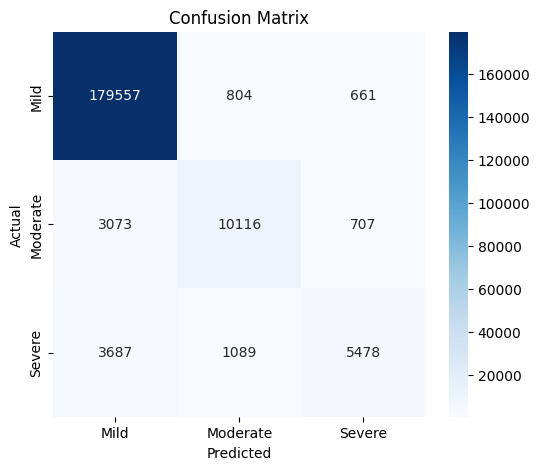

In [17]:
#comfusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Mild","Moderate","Severe"],
            yticklabels=["Mild","Moderate","Severe"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [18]:
#Severe Misclassification check
error_df = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": y_pred
})

severe_errors = error_df[
    (error_df["actual"] == "Severe") &
    (error_df["predicted"] == "Mild")
]

severe_errors.head(10)

,text,actual,predicted
261311,I had mild tinnitus and now it is severe after...,Severe,Mild
639647,Bell's Palsy. Complete paralysis of right face...,Severe,Mild
848026,"Narrative: , received a ""booster"" dose of Mode...",Severe,Mild
311544,Patient presented to her PCP office on 04/20 r...,Severe,Mild
544500,"Swollen lips for 5 weeks straight, lesions in ...",Severe,Mild
143393,Other side effects; Anaphylaxis; Anaphylaxis; ...,Severe,Mild
895906,"Left Bell's Palsy (did not fully resolve, stil...",Severe,Mild
131324,Acute onset rep distress,Severe,Mild
824707,"Breathing issues (oxygen drops) heart attack, ...",Severe,Mild
265014,"Fever, Dizziness, Disorientation, Weakness, St...",Severe,Mild


Model detected some severe cases as Mild such as “Complete paralysis of right face”, “expired at 4:48 P.M.”, “DVT in right peroneal veins”, “anaphylaxis… rushed to ER… epinephrine”, “heart attack”, “respiratory distress”, “fell twice and hit his head”.

In [21]:

feature_names = pipeline.named_steps["tfidf"].get_feature_names_out()

coefs = pipeline.named_steps["clf"].coef_

topn = 20

for i, class_label in enumerate(pipeline.named_steps["clf"].classes_):
    top_features = np.argsort(coefs[i])[-topn:]
    print("\nClass:", class_label)
    print(", ".join(feature_names[top_features]))


Class: Mild
contact, paxlovid, 1273 moderna, bud, administered, vial, expired vaccine, report medically, storage, stored, vaccine expired, use date, instead, non onset, expired, medically significant, requiring hospitalization, error, medically, criterion medically

Class: Moderate
hospitalization caused, criteria hospitalization, report hospitalization, hypoxia, hospital days, outside source, 21 positive, admission, pmhx, presents, unspecified, hospitalization outcome, hospitalization onset, hospital, patient hospitalized, admitted, hospitalized, criterion hospitalization, hospitalization, hospitalization medically

Class: Severe
disability medically, dnr, hospice, intubated, cpr, comfort, permanent, cause death, patient died, disability onset, dead, patient expired, threatening, life threatening, expired, deceased, passed away, died, death, disability


In [22]:
df["SEVERITY_LEVEL"].value_counts(normalize=True)

,proportion
SEVERITY_LEVEL,
Mild,0.882295
Moderate,0.067730
Severe,0.049976


In [23]:
#balanced model
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1,2),
        stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [24]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [25]:
y_pred = pipeline.predict(X_test)

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Mild       0.99      0.91      0.95    181022
    Moderate       0.64      0.83      0.72     13896
      Severe       0.39      0.77      0.52     10254

    accuracy                           0.90    205172
   macro avg       0.67      0.84      0.73    205172
weighted avg       0.94      0.90      0.91    205172



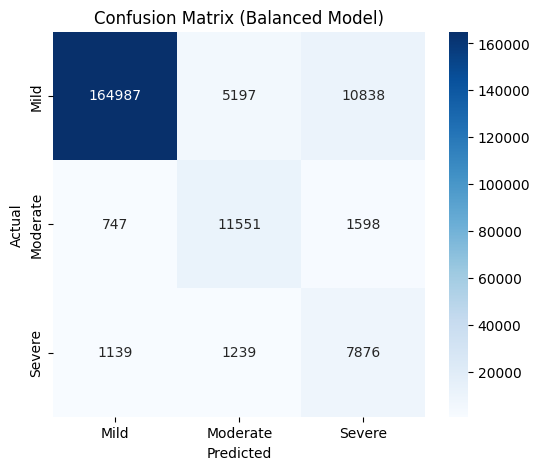

In [27]:
#confustion matrix for balanced model
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Mild","Moderate","Severe"],
            yticklabels=["Mild","Moderate","Severe"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Balanced Model)")
plt.show()

In [28]:
#create feature matrix
X = df[["SYMPTOM_TEXT", "SEX", "AGE_GROUP"]]
y = df["SEVERITY_LEVEL"]

In [29]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import FunctionTransformer
from scipy.sparse import hstack

In [44]:
X_train_meta = pd.get_dummies(X_train[["SEX", "AGE_GROUP"]])
X_test_meta = pd.get_dummies(X_test[["SEX", "AGE_GROUP"]])

In [52]:
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,3),
    stop_words="english",
    min_df=5
)

In [53]:
X_train_text = tfidf.fit_transform(X_train["SYMPTOM_TEXT"])
X_test_text = tfidf.transform(X_test["SYMPTOM_TEXT"])

In [54]:
X_train_final = hstack([X_train_text, X_train_meta])
X_test_final = hstack([X_test_text, X_test_meta])

In [48]:
X_train_final.shape

(820688, 20008)

In [56]:

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_final, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [57]:
y_pred = model.predict(X_test_final)

In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Mild       0.99      0.91      0.95    181022
    Moderate       0.65      0.83      0.73     13896
      Severe       0.39      0.77      0.52     10254

    accuracy                           0.90    205172
   macro avg       0.68      0.84      0.73    205172
weighted avg       0.94      0.90      0.91    205172



In [60]:
import joblib

joblib.dump(model,"/content/drive/MyDrive/ADEGuard/models/severity_model.pkl")
joblib.dump(tfidf,"/content/drive/MyDrive/ADEGuard/models/tfidf_vectorizer.pkl")

['/content/drive/MyDrive/ADEGuard/models/tfidf_vectorizer.pkl']